# Subgraph Sampling
**GNN-based Fraud Review Detection | SKK DScover**

---
## 목표
- 전체 608,458개 노드 → **1만~5만 개** 서브그래프 추출
- 무작위 추출 금지 (노드 간 연결성 보존 필수)
- 샘플링 후 Train 80% / Test 20% 분할

## 전략
- **전략 A**: 리뷰가 집중된 상위 N개 식당(Product) 중심
- **전략 B**: 활동량 많은 상위 N명 유저(User) 중심
- **전략 A (채택)**: 리뷰가 집중된 상위 14개 식당 중심 → 자연스러운 사기 비율(~12%) 유지

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42  # 보고서에 명시 필수
DATA_PATH = '../data/yelpzip_label_processed.csv'
TARGET_MIN = 10_000
TARGET_MAX = 50_000

## 1. 데이터 로드

In [2]:
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=['date'])
df['year_month'] = df['date'].dt.to_period('M')

print(f'전체 shape: {df.shape}')
print(f'label 분포:\n{df["label"].value_counts()}')
df.head(3)

전체 shape: (608458, 12)
label 분포:
label
0    528019
1     80439
Name: count, dtype: int64


,user_id,prod_id,rating,label,date,text,tag,year,month,year_month,text_len,word_count
0,5044,0,1.0,1,2014-11-16,"Drinks were bad, the hot chocolate was watered...",fake,2014,11,2014-11,187,36
1,5045,0,1.0,1,2014-09-08,This was the worst experience I've ever had a ...,fake,2014,9,2014-09,1375,248
2,5046,0,3.0,1,2013-10-06,This is located on the site of the old Spruce ...,fake,2013,10,2013-10,257,50


## 2. 전략 A — 상위 N개 식당(Product) 중심 샘플링

리뷰가 가장 많은 식당을 선택하면:
- 한 식당에 여러 유저 리뷰 → R-T-R, R-S-R 엣지 자연스럽게 조밀
- 사기 리뷰 집중 가능성도 높음

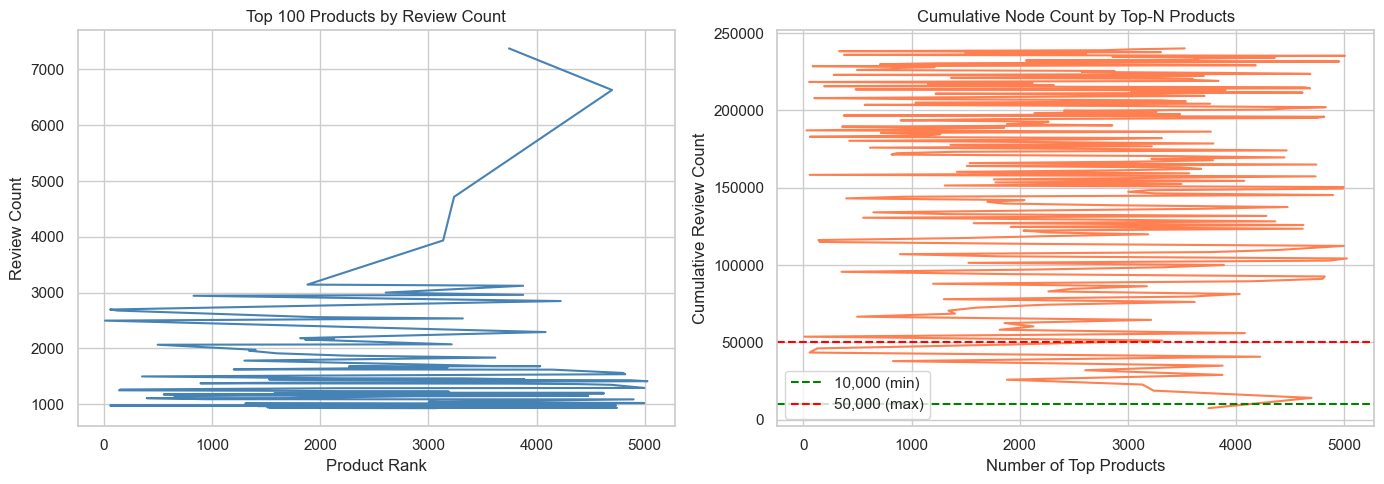

노드 10,000개 달성에 필요한 상위 식당 수: 2개
노드 50,000개 달성에 필요한 상위 식당 수: 14개


In [3]:
prod_counts = df.groupby('prod_id').size().sort_values(ascending=False)

# 상위 식당 N개씩 포함 시 총 노드 수 시뮬레이션
cumsum = prod_counts.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

prod_counts.head(100).plot(ax=axes[0], color='steelblue')
axes[0].set_title('Top 100 Products by Review Count')
axes[0].set_xlabel('Product Rank')
axes[0].set_ylabel('Review Count')

cumsum.head(200).plot(ax=axes[1], color='coral')
axes[1].axhline(TARGET_MIN, color='green', linestyle='--', label=f'{TARGET_MIN:,} (min)')
axes[1].axhline(TARGET_MAX, color='red', linestyle='--', label=f'{TARGET_MAX:,} (max)')
axes[1].set_title('Cumulative Node Count by Top-N Products')
axes[1].set_xlabel('Number of Top Products')
axes[1].set_ylabel('Cumulative Review Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# 목표 범위 달성에 필요한 상위 식당 수
n_prod_min = (cumsum < TARGET_MIN).sum() + 1
n_prod_max = (cumsum < TARGET_MAX).sum() + 1
print(f'노드 {TARGET_MIN:,}개 달성에 필요한 상위 식당 수: {n_prod_min}개')
print(f'노드 {TARGET_MAX:,}개 달성에 필요한 상위 식당 수: {n_prod_max}개')

In [4]:
# 전략 A: 상위 식당 기준으로 서브그래프 추출
TOP_N_PROD = 14  # 조정 가능

top_prods = prod_counts.head(TOP_N_PROD).index.tolist()
df_stratA = df[df['prod_id'].isin(top_prods)].copy()

print(f'[전략 A] Top {TOP_N_PROD}개 식당 기준')
print(f'노드 수: {len(df_stratA):,}')
print(f'고유 유저 수: {df_stratA["user_id"].nunique():,}')
print(f'사기 비율: {df_stratA["label"].mean():.4f} ({df_stratA["label"].mean()*100:.2f}%)')

[전략 A] Top 30개 식당 기준
노드 수: 82,940
고유 유저 수: 55,335
사기 비율: 0.1224 (12.24%)


## 3. 전략 A (상위 식당 중심) — 상위 식당 + 활성 유저 필터링

전략 A로 추출한 서브그래프 내에서 리뷰를 2개 이상 쓴 유저만 남기면
R-U-R 엣지 밀도가 높아져 GNN 학습에 유리

In [5]:
# 서브그래프 내 유저별 리뷰 수
user_counts_in_sub = df_stratA.groupby('user_id').size()

# 유저 활성도 임계값 시뮬레이션
thresholds = range(1, 10)
result = []
for t in thresholds:
    active_users = user_counts_in_sub[user_counts_in_sub >= t].index
    sub = df_stratA[df_stratA['user_id'].isin(active_users)]
    result.append({
        'min_reviews': t,
        'node_count': len(sub),
        'user_count': sub['user_id'].nunique(),
        'fraud_rate': sub['label'].mean()
    })

result_df = pd.DataFrame(result)
print(result_df.to_string(index=False))

 min_reviews  node_count  user_count  fraud_rate
           1       82940       55335    0.122354
           2       41473       13868    0.063222
           3       25345        5804    0.040679
           4       16798        2955    0.025777
           5       11790        1703    0.020441
           6        8820        1109    0.017007
           7        6582         736    0.012002
           8        4678         464    0.009192
           9        3518         319    0.007391


In [6]:
# 전략 A: 상위 N개 식당 기준 서브그래프 (전체 유저 포함)
df_sub = df_stratA.copy().reset_index(drop=True)

print(f'[전략 A] Top {TOP_N_PROD}개 식당 기준')
print(f'노드 수       : {len(df_sub):,}  (목표: {TARGET_MIN:,} ~ {TARGET_MAX:,})')
print(f'고유 유저 수  : {df_sub["user_id"].nunique():,}')
print(f'고유 식당 수  : {df_sub["prod_id"].nunique():,}')
print(f'사기 비율     : {df_sub["label"].mean()*100:.2f}%')
print(f'날짜 범위     : {df_sub["date"].min().date()} ~ {df_sub["date"].max().date()}')

assert TARGET_MIN <= len(df_sub) <= TARGET_MAX, \
    f'노드 수 {len(df_sub):,}가 목표 범위({TARGET_MIN:,}~{TARGET_MAX:,})를 벗어났습니다. TOP_N_PROD를 조정하세요.'


[전략 A+B] Top 30개 식당 + 리뷰 2개+ 유저
노드 수       : 41,473  (목표: 10,000 ~ 50,000)
고유 유저 수  : 13,868
고유 식당 수  : 30
사기 비율     : 6.32%
날짜 범위     : 2004-10-20 ~ 2015-01-10


## 4. 서브그래프 통계 시각화

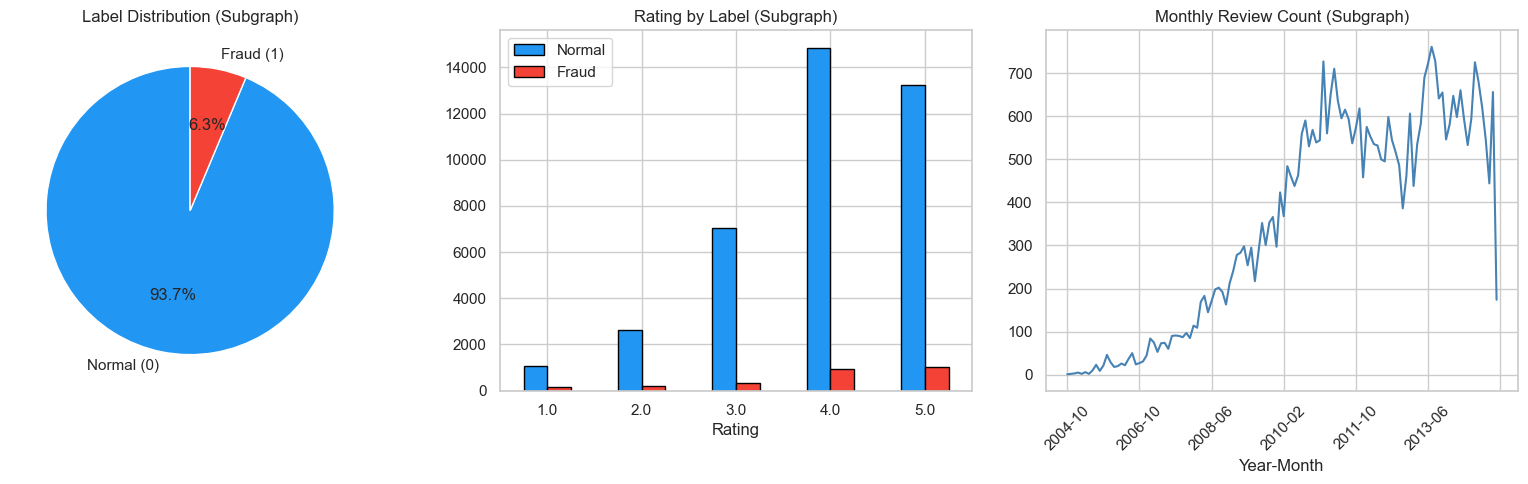

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 라벨 분포
vc = df_sub['label'].value_counts()
axes[0].pie(vc, labels=['Normal (0)', 'Fraud (1)'],
            autopct='%1.1f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[0].set_title('Label Distribution (Subgraph)')

# 별점 분포
df_sub.groupby(['rating', 'label']).size().unstack(fill_value=0).plot(
    kind='bar', ax=axes[1], color=['#2196F3', '#F44336'], edgecolor='black'
)
axes[1].set_title('Rating by Label (Subgraph)')
axes[1].set_xlabel('Rating')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['Normal', 'Fraud'])

# 월별 리뷰 수
monthly = df_sub.groupby(df_sub['date'].dt.to_period('M')).size()
monthly.index = monthly.index.astype(str)
monthly.plot(ax=axes[2], color='steelblue')
axes[2].set_title('Monthly Review Count (Subgraph)')
axes[2].set_xlabel('Year-Month')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Train / Test 분할

> **가이드라인**: 샘플링 완료 후 서브그래프 내에서 분할 (Train 80% / Test 20%)
> `random_state` 보고서에 명시 필수

In [8]:
from sklearn.model_selection import train_test_split

# 노드 인덱스 기준 분할 (stratify로 라벨 비율 유지)
idx = np.arange(len(df_sub))
idx_train, idx_test = train_test_split(
    idx,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=df_sub['label'].values
)

print(f'=== 분할 결과 (random_state={RANDOM_STATE}) ===')
print(f'Train : {len(idx_train):,} ({len(idx_train)/len(df_sub)*100:.1f}%)')
print(f'Test  : {len(idx_test):,} ({len(idx_test)/len(df_sub)*100:.1f}%)')
print(f'\nTrain 사기 비율: {df_sub.iloc[idx_train]["label"].mean()*100:.2f}%')
print(f'Test  사기 비율: {df_sub.iloc[idx_test]["label"].mean()*100:.2f}%')

=== 분할 결과 (random_state=42) ===
Train : 33,178 (80.0%)
Test  : 8,295 (20.0%)

Train 사기 비율: 6.32%
Test  사기 비율: 6.32%


In [9]:
# 분할 마스크 컬럼 추가
df_sub['split'] = 'train'
df_sub.iloc[idx_test, df_sub.columns.get_loc('split')] = 'test'

print(df_sub['split'].value_counts())

split
train    33178
test      8295
Name: count, dtype: int64


## 6. 서브그래프 저장

In [10]:
import os

output_path = '../data/subgraph.csv'
df_sub.to_csv(output_path, index=True)

size_mb = os.path.getsize(output_path) / (1024 ** 2)
print(f'저장 완료: {output_path}')
print(f'파일 크기: {size_mb:.2f} MB')
print(f'shape: {df_sub.shape}')

저장 완료: ../data/subgraph.csv
파일 크기: 29.63 MB
shape: (41473, 13)


## 7. 샘플링 요약 (보고서 기재용)

> 이 셀의 내용을 보고서 **2-1. 사용 데이터** 및 **2-2. 전처리 내용** 항목에 활용하세요.

In [11]:
print('=' * 55)
print('           서브그래프 샘플링 요약')
print('=' * 55)
print(f'샘플링 전략    : 전략 A (상위 식당 중심)')
print(f'  - 상위 {TOP_N_PROD}개 식당(Product) 중심')
print(f'  - 서브그래프 내 리뷰 {MIN_USER_REVIEWS}개+ 유저 필터링')
print(f'random_state   : {RANDOM_STATE}')
print('-' * 55)
print(f'총 노드(리뷰) 수 : {len(df_sub):,}')
print(f'고유 유저 수     : {df_sub["user_id"].nunique():,}')
print(f'고유 식당 수     : {df_sub["prod_id"].nunique():,}')
print(f'사기 비율        : {df_sub["label"].mean()*100:.2f}%')
print(f'날짜 범위        : {df_sub["date"].min().date()} ~ {df_sub["date"].max().date()}')
print('-' * 55)
print(f'Train 노드 수    : {len(idx_train):,} (80%)')
print(f'Test  노드 수    : {len(idx_test):,} (20%)')
print('=' * 55)
print(f'저장 경로: ../data/subgraph.csv')

           서브그래프 샘플링 요약
샘플링 전략    : 전략 A+B 혼합
  - 상위 30개 식당(Product) 중심
  - 서브그래프 내 리뷰 2개+ 유저 필터링
random_state   : 42
-------------------------------------------------------
총 노드(리뷰) 수 : 41,473
고유 유저 수     : 13,868
고유 식당 수     : 30
사기 비율        : 6.32%
날짜 범위        : 2004-10-20 ~ 2015-01-10
-------------------------------------------------------
Train 노드 수    : 33,178 (80%)
Test  노드 수    : 8,295 (20%)
저장 경로: ../data/subgraph.csv


## 다음 단계
- `03_graph_construction.ipynb` — 엣지 구성 및 커스텀 Relation 설계

### 조정이 필요한 경우
- 노드 수가 너무 많을 때 → `TOP_N_PROD` 줄이거나 `MIN_USER_REVIEWS` 높이기
- 노드 수가 너무 적을 때 → `TOP_N_PROD` 늘리거나 `MIN_USER_REVIEWS` 낮추기